In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.94MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 116kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 995kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.98MB/s]


In [3]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [4]:
images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Label shape:", labels.shape)

Image shape: torch.Size([64, 1, 28, 28])
Label shape: torch.Size([64])


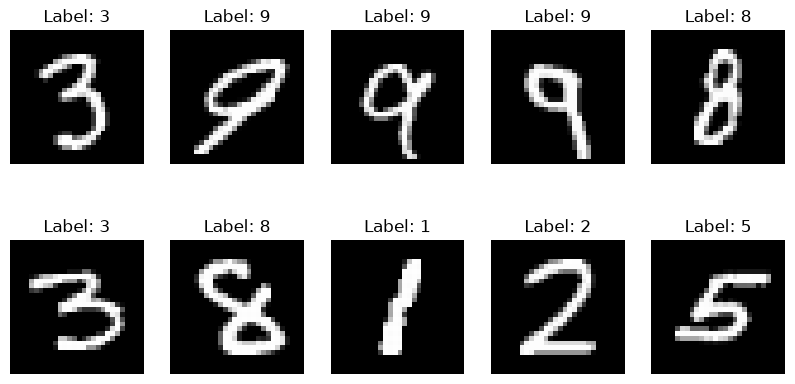

In [5]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.show()

## Build the CNN

In [6]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 128),

            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [8]:
cnn_model = CNN() 
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=0.001
)

## Train CNN

In [9]:
epochs = 10

for epoch in range(epochs):

    cnn_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images
        labels = labels

        optimizer.zero_grad()

        outputs = cnn_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predictions = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predictions == labels).sum().item()

    accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {running_loss/len(train_loader):.4f} "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch [1/10] Loss: 0.1787 Accuracy: 94.60%
Epoch [2/10] Loss: 0.0506 Accuracy: 98.42%
Epoch [3/10] Loss: 0.0346 Accuracy: 98.92%
Epoch [4/10] Loss: 0.0255 Accuracy: 99.17%
Epoch [5/10] Loss: 0.0196 Accuracy: 99.38%
Epoch [6/10] Loss: 0.0155 Accuracy: 99.50%
Epoch [7/10] Loss: 0.0129 Accuracy: 99.59%
Epoch [8/10] Loss: 0.0097 Accuracy: 99.71%
Epoch [9/10] Loss: 0.0088 Accuracy: 99.70%
Epoch [10/10] Loss: 0.0077 Accuracy: 99.76%


## Evaluate the Model

In [10]:
cnn_model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images
        labels = labels

        outputs = cnn_model(images)

        _, predictions = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predictions == labels).sum().item()

        all_predictions.extend(predictions.numpy())
        all_labels.extend(labels.numpy())

cnn_accuracy = 100 * correct / total

print(f"CNN Test Accuracy: {cnn_accuracy:.2f}%")

CNN Test Accuracy: 99.02%


## CNN confusion matrix

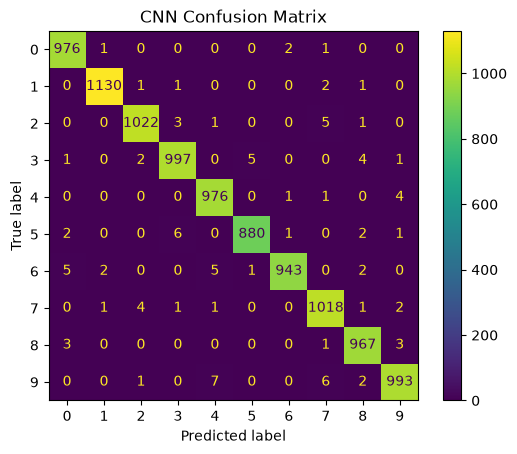

In [11]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

disp.plot()

plt.title("CNN Confusion Matrix")
plt.show()

## RNN architecture

In [12]:

class RNN(nn.Module):

    def __init__(
        self,
        input_size=28,
        hidden_size=128,
        num_layers=1
    ):

        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            10
        )

    def forward(self, x):

        # x = [batch, 1, 28, 28]

        x = x.squeeze(1)

        # x = [batch, 28, 28]

        h0 = torch.zeros(
            self.num_layers,
            x.size(0),
            self.hidden_size
        ).to(x.device)

        output, hidden = self.rnn(
            x,
            h0
        )

        # Take the final time step

        output = output[:, -1, :]

        output = self.fc(output)

        return output

In [13]:
rnn_model = RNN()
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    rnn_model.parameters(),
    lr=0.001
)


## Build RNN model

In [14]:
epochs = 10

for epoch in range(epochs):

    rnn_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images
        labels = labels

        optimizer.zero_grad()

        outputs = rnn_model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predictions = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

    accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {running_loss/len(train_loader):.4f} "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch [1/10] Loss: 0.7096 Accuracy: 76.38%
Epoch [2/10] Loss: 0.3062 Accuracy: 91.19%
Epoch [3/10] Loss: 0.2381 Accuracy: 93.24%
Epoch [4/10] Loss: 0.2029 Accuracy: 94.16%
Epoch [5/10] Loss: 0.1767 Accuracy: 95.03%
Epoch [6/10] Loss: 0.1586 Accuracy: 95.44%
Epoch [7/10] Loss: 0.1497 Accuracy: 95.75%
Epoch [8/10] Loss: 0.1344 Accuracy: 96.23%
Epoch [9/10] Loss: 0.1295 Accuracy: 96.30%
Epoch [10/10] Loss: 0.1167 Accuracy: 96.70%


## Evaluate RNN 

In [16]:
rnn_model.eval()

correct = 0
total = 0

rnn_predictions = []
rnn_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images
        labels = labels

        outputs = rnn_model(images)

        _, predictions = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

        rnn_predictions.extend(
            predictions.numpy()
        )

        rnn_labels.extend(
            labels.numpy()
        )

rnn_accuracy = 100 * correct / total

print(f"RNN Test Accuracy: {rnn_accuracy:.2f}%")

RNN Test Accuracy: 96.94%


## Compare CNN and RNN

In [17]:
print(f"CNN Accuracy: {cnn_accuracy:.2f}%")
print(f"RNN Accuracy: {rnn_accuracy:.2f}%")

CNN Accuracy: 99.02%
RNN Accuracy: 96.94%
